New feature 'Tenure_Category' created successfully!


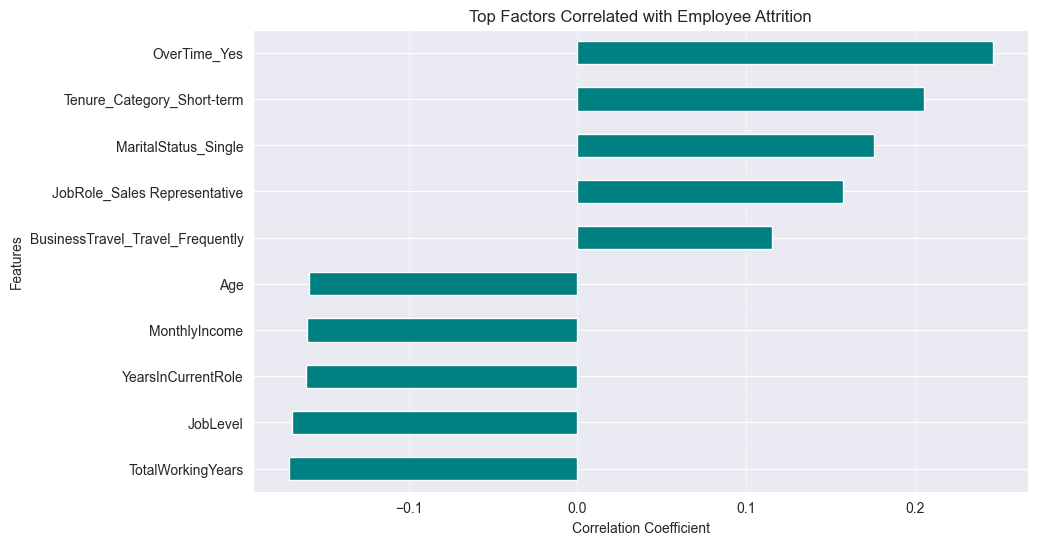

Processed dataset saved! Shape: (1470, 47)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the raw data
df = pd.read_csv('../data/raw/employee_attrition_raw.csv')

# ==========================================
# Task 1: Feature Engineering
# ==========================================
# Creating a new feature: Tenure Categories based on 'YearsAtCompany'
def categorize_tenure(years):
    if years < 3:
        return 'Short-term'
    elif years <= 7:
        return 'Medium-term'
    else:
        return 'Long-term'

df['Tenure_Category'] = df['YearsAtCompany'].apply(categorize_tenure)
print("New feature 'Tenure_Category' created successfully!")

# ==========================================
# Task 2: Data Cleaning (Drop useless columns)
# ==========================================
# EmployeeNumber is just an ID. Over18, StandardHours, EmployeeCount have the same value for everyone.
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_cleaned = df.drop(columns=cols_to_drop)

# ==========================================
# Task 3: Data Encoding (Convert Text to Numbers)
# ==========================================
# We use get_dummies to convert categorical columns to numerical ones (0 and 1)
# drop_first=True helps avoid the dummy variable trap
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

# Because we used drop_first=True, 'Attrition' (Yes/No) became 'Attrition_Yes' (1/0)
target_col = 'Attrition_Yes'

# ==========================================
# Task 4: Correlation Analysis
# ==========================================
# Let's see which features have the highest correlation with Attrition
plt.figure(figsize=(10, 6))
corr_with_target = df_encoded.corr()[target_col].drop(target_col).sort_values()

# Plot the top 5 positive and top 5 negative correlations
top_factors = pd.concat([corr_with_target.head(5), corr_with_target.tail(5)])
top_factors.plot(kind='barh', color='teal')
plt.title('Top Factors Correlated with Employee Attrition')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# Task 5: Save Processed Data
# ==========================================
import os
os.makedirs('../data/processed', exist_ok=True)
df_encoded.to_csv('../data/processed/employee_attrition_processed.csv', index=False)
print(f"Processed dataset saved! Shape: {df_encoded.shape}")